# Código para crear gráficas a partir de los resultados

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

## Configuración sin desconocidos

In [3]:
resultados_sin_desconocidos='resultados_completo.xlsx'
df = pd.read_excel(resultados_sin_desconocidos)

#### 5.2.4 Comparativa visual de los resultados

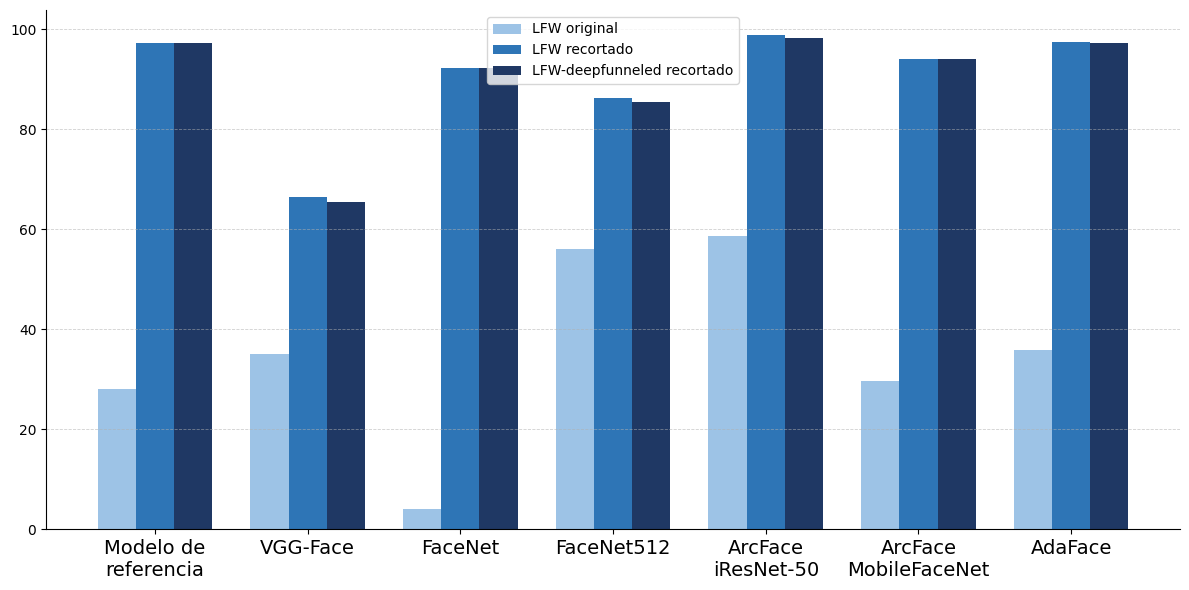

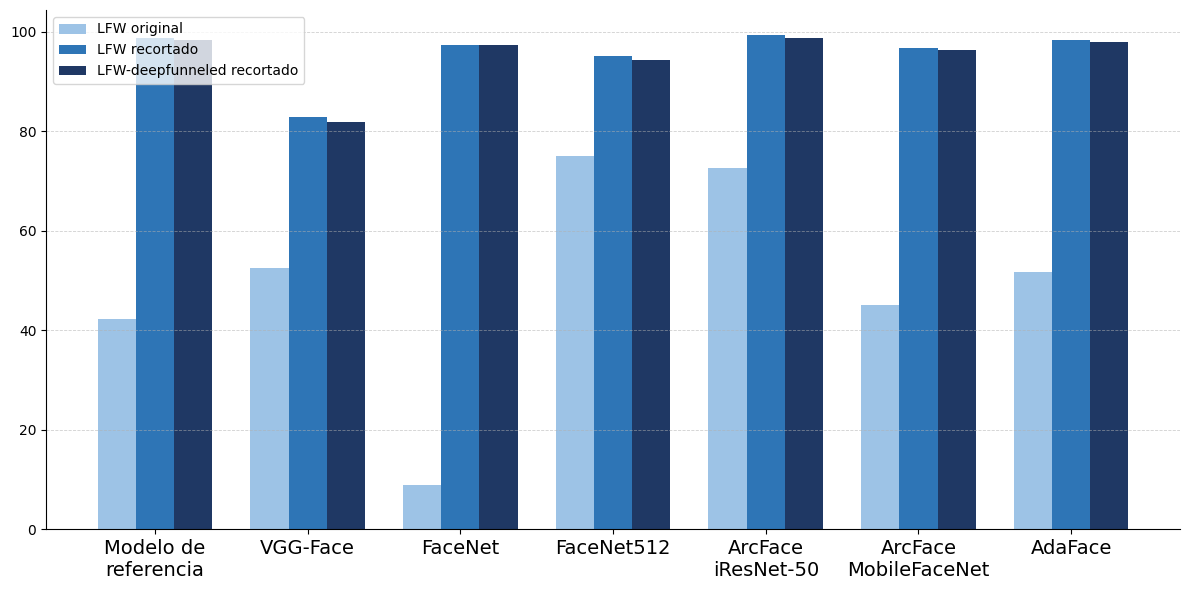

In [4]:
datasets = ['lfw_filtrado', 'lfw_cropped', 'lfw-deepfunneled_cropped'] #datasets a comparar 
labels_datasets = ['LFW original', 'LFW recortado', 'LFW-deepfunneled recortado'] 

modelos = ['empresa', 'VGG-Face', 'Facenet', 'Facenet512', 'ArcFace', 'ArcFace_s', 'AdaFace'] #modelos a comparar
labels_modelos = ['Modelo de\nreferencia', 'VGG-Face', 'FaceNet', 'FaceNet512', 'ArcFace\niResNet-50', 'ArcFace\nMobileFaceNet', 'AdaFace']

colores_barras = ['#9DC3E6', '#2E75B6', '#1F3864'] 

df_cos = df[df['metric'] == 'cosine'] #solo los resultados de distancia coseno
x = np.arange(len(modelos)) #posiciones en el eje X, una por modelo
width = 0.25 #ancho de cada barra

for metric, filename in [('rank1', 'rank1_results_sin.pdf'), ('rank5', 'rank5_results_sin.pdf')]: #para cada métrica se genera un gráfico distinto
    fig, ax = plt.subplots(figsize=(12, 6)) #crea la figura
    for i, (dataset, label_ds) in enumerate(zip(datasets, labels_datasets)): #para cada dataset
        
        valores = []
        for modelo in modelos:
            fila = df_cos[(df_cos['modelo'] == modelo) & (df_cos['dataset'] == dataset)] #valor del modelo y dataset
            valores.append(fila[metric].values[0] if not fila.empty else 0) 
        
        ax.bar(x + i * width, valores, width, label=label_ds, color=colores_barras[i]) #dibuja las barras

    ax.set_xticks(x + width)  #centra las etiquetas del eje X respecto al grupo de barras
    ax.set_xticklabels(labels_modelos, rotation=0, ha='center', fontsize=14) #etiquetas del eje x
    ax.legend() #leyenda
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.6) #rejilla horizontal
    ax.spines[['top', 'right']].set_visible(False) #oculta los bordes superior y derecho
    plt.tight_layout() #ajusta los márgenes
    # plt.savefig(filename, bbox_inches='tight')
    # print(f'Guardada: {filename}')
    plt.show()

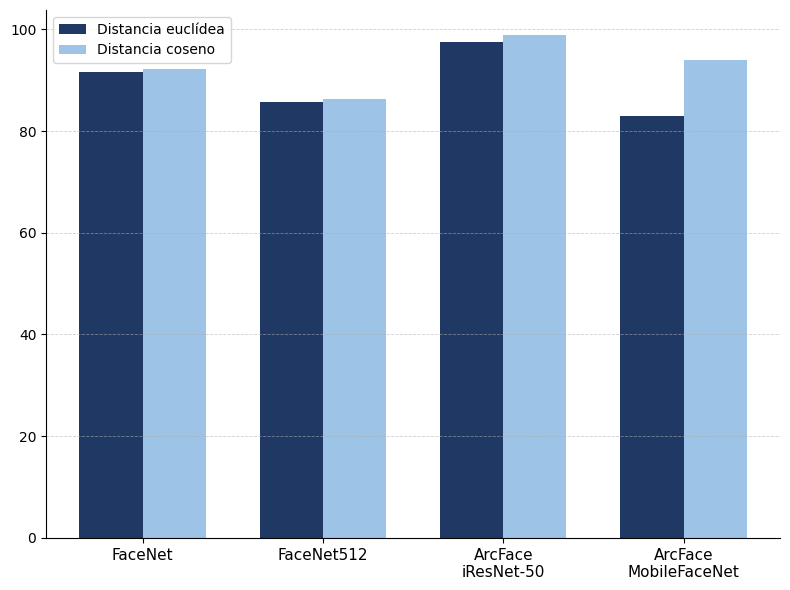

In [5]:
modelos = ['Facenet', 'Facenet512', 'ArcFace', 'ArcFace_s'] #modelos a comparar
labels_modelos = ['FaceNet', 'FaceNet512', 'ArcFace\niResNet-50', 'ArcFace\nMobileFaceNet'] 

colores_barras = ['#1F3864', '#9DC3E6'] 

df_cropped = df[df['dataset'] == 'lfw_cropped'] #solo usa los resultados de LFW recortado

x = np.arange(len(modelos)) #posiciones en el eje X, una por modelo
width = 0.35 #ancho de cada barra

fig, ax = plt.subplots(figsize=(8, 6)) #crea la figura

valores_cos = [] #valores de rank1 con distancia coseno
valores_euc = [] #valores de rank2 con distancia euclídea
for modelo in modelos: #para cada modelo
    fila_cos = df_cropped[(df_cropped['modelo'] == modelo) & (df_cropped['metric'] == 'cosine')] #fila de este modelo con distancia coseno
    fila_euc = df_cropped[(df_cropped['modelo'] == modelo) & (df_cropped['metric'] == 'euclidean')] #fila de este modelo con distancia euclídea
    valores_cos.append(fila_cos['rank1'].values[0] if not fila_cos.empty else 0)
    valores_euc.append(fila_euc['rank1'].values[0] if not fila_euc.empty else 0)

#crea las barras
ax.bar(x - width/2, valores_euc, width, label='Distancia euclídea', color=colores_barras[0])
ax.bar(x + width/2, valores_cos, width, label='Distancia coseno', color=colores_barras[1])

ax.set_xticks(x) #centra las etiquetas del eje X respecto al grupo de barras
ax.set_xticklabels(labels_modelos, rotation=0, ha='center', fontsize=11) #etiquetas eje X
ax.legend() #leyenda
ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.6) #rejilla horizontal
ax.spines[['top', 'right']].set_visible(False) #oculta los bordes superior y derecho del gráfico
plt.tight_layout() #ajusta los márgenes
# plt.savefig('rank1_distancias_sin.pdf', dpi=150, bbox_inches='tight')
# print('Guardada: rank1_distancias_sin.pdf')
plt.show()

#### 5.2.5 LFW con ruido gaussiano

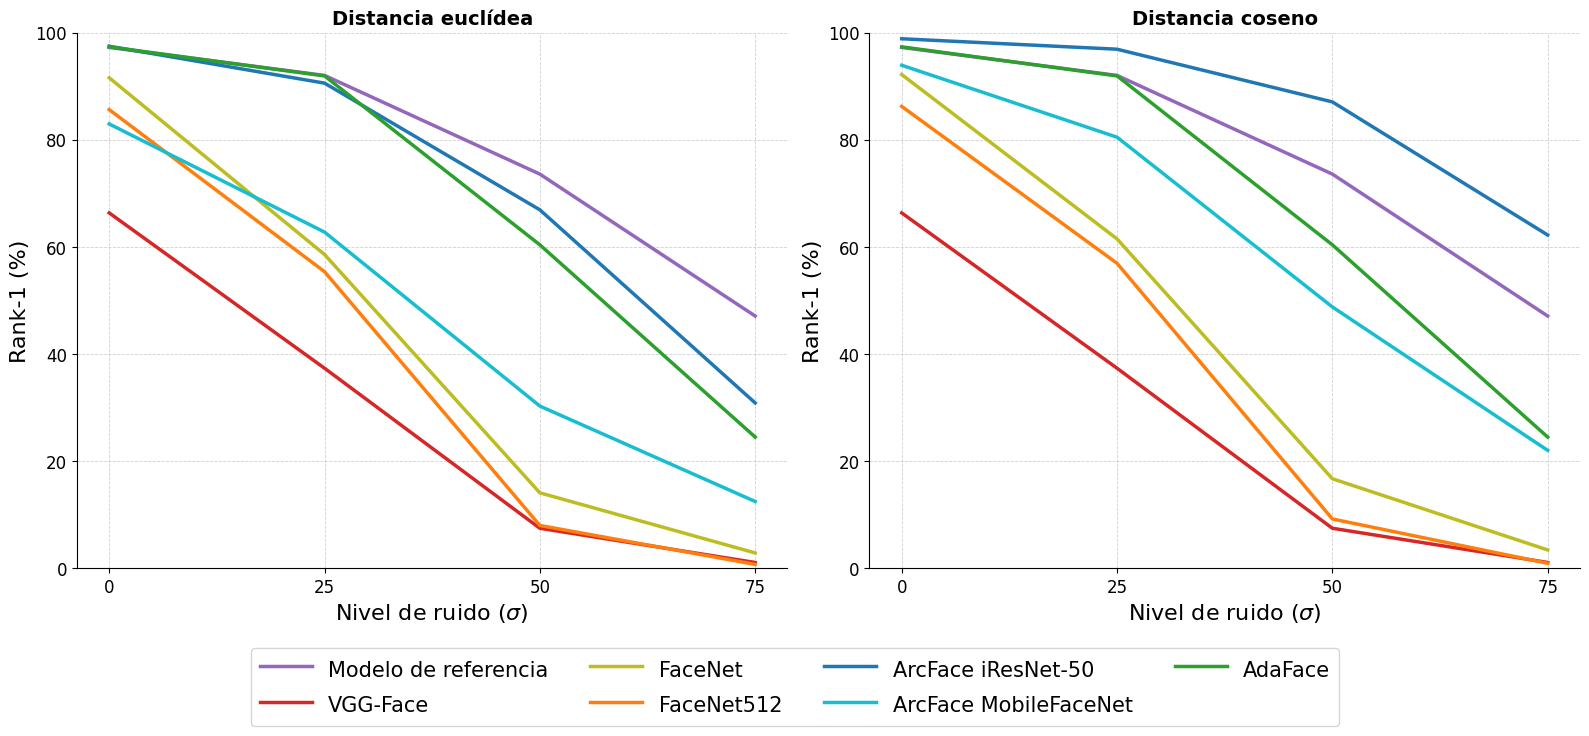

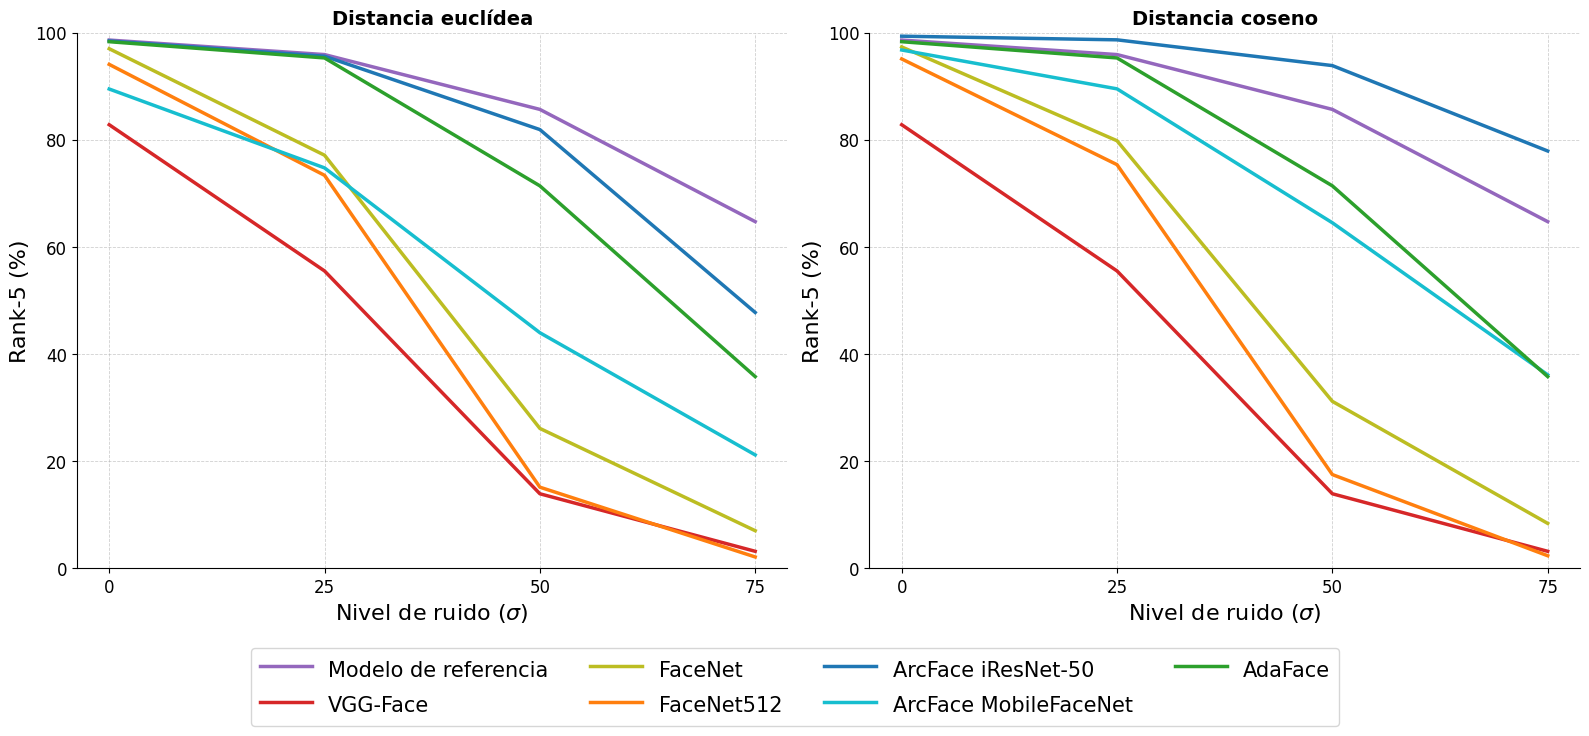

In [6]:
NOISE_LEVELS = [0, 25, 50, 75] #niveles de ruido
DATASETS = ['lfw_cropped', 'lfw_noisy_25', 'lfw_noisy_50', 'lfw_noisy_75'] #datasets 

MODELOS = {'empresa':'Modelo de referencia','VGG-Face':'VGG-Face','Facenet':'FaceNet','Facenet512':'FaceNet512','ArcFace':'ArcFace iResNet-50','ArcFace_s':'ArcFace MobileFaceNet','AdaFace':'AdaFace',} #modelos a comparar

STYLE = {'empresa':{'color': '#9467BD'},'VGG-Face':{'color': '#D62728'},'Facenet':{'color': '#BCBD22'},'Facenet512': {'color': '#FF7F0E'},'ArcFace':{'color': '#1F77B4'},'ArcFace_s':{'color': '#17BECF'},'AdaFace':{'color': '#2CA02C'},}

#configuración de cada gráfico
PLOTS = [{'metric': 'rank1', 'ylabel': 'Rank-1 (%)', 'filename': 'rank1_ruido_sin.pdf'},{'metric': 'rank5', 'ylabel': 'Rank-5 (%)', 'filename': 'rank5_ruido_sin.pdf'},]

for cfg in PLOTS: #genera una figura para cada métrica
    fig, axes = plt.subplots(1, 2, figsize=(16, 7)) #dos gráficos por figura
    handles, labels = None, None #leyenda común

    for ax, distancia, titulo in zip(axes, ['euclidean', 'cosine'],['Distancia euclídea', 'Distancia coseno']): #para cada gráfico
        for modelo, label in MODELOS.items():
            valores = []
            for dataset in DATASETS: #para cada dataset
                fila = df[(df['modelo'] == modelo) &(df['dataset'] == dataset) &(df['metric'] == distancia)] #para cada dataset
                valores.append(fila[cfg['metric']].values[0] if not fila.empty else None)
            #crea la figura
            ax.plot(NOISE_LEVELS, valores, label=label,color=STYLE[modelo]['color'],linestyle='-',linewidth=2.5)

        ax.set_title(titulo, fontsize=14, fontweight='bold') #título del gráfico
        ax.set_xlabel('Nivel de ruido ($\\sigma$)', fontsize=16)
        ax.set_ylabel(cfg['ylabel'], fontsize=16)
        ax.set_xticks(NOISE_LEVELS) #una marca por nivel de ruido
        ax.tick_params(axis='both', labelsize=12)
        ax.set_ylim(0, 100) #eje y entre 0 y 100
        ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6) #rejilla
        ax.spines[['top', 'right']].set_visible(False) #oculta los bordes superior y derecho

        if handles is None: #solo la primera vez (subgráfico de euclídea) se guarda la leyenda
            handles, labels = ax.get_legend_handles_labels()
    #configuración de la leyenda
    fig.legend(handles, labels,loc='lower center',ncol=4,fontsize=15,bbox_to_anchor=(0.5, -0.06),handlelength=2.5,handleheight=1.5,markerscale=2)

    plt.tight_layout() #ajusta los márgenes
    plt.subplots_adjust(bottom=0.18) #deja espacio extra abajo para la leyenda común
    save_path =  cfg['filename']
    #plt.savefig(save_path, dpi=150, bbox_inches='tight')
    #print(f'Guardada: {save_path}')
    plt.show()

## Configuración con desconocidos

#### 5.3.4 Comparativa visual de los resultados

In [7]:
resultados_con_desconocidos='resultados_openset_completo.xlsx'
df = pd.read_excel(resultados_con_desconocidos)

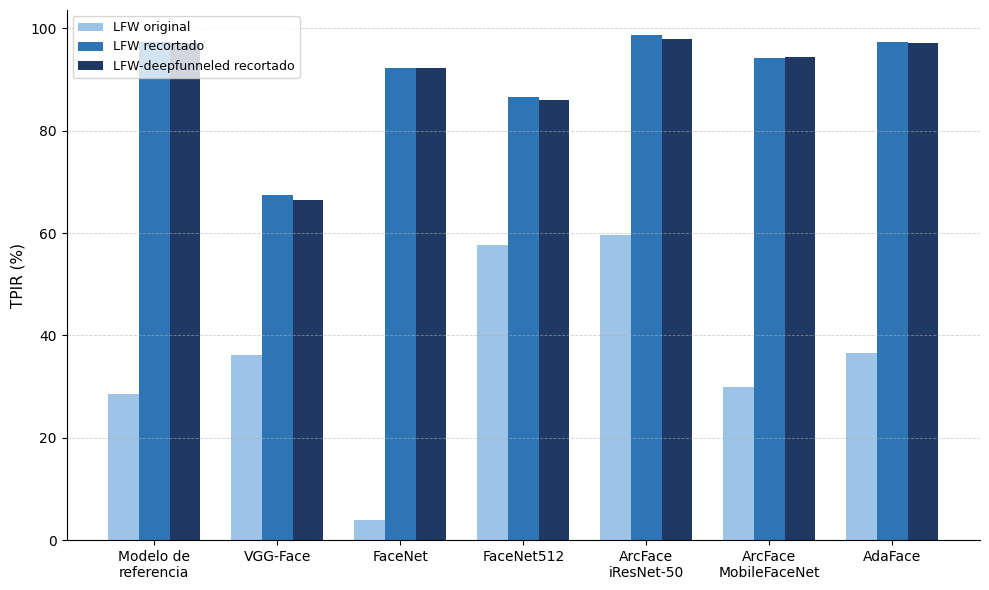

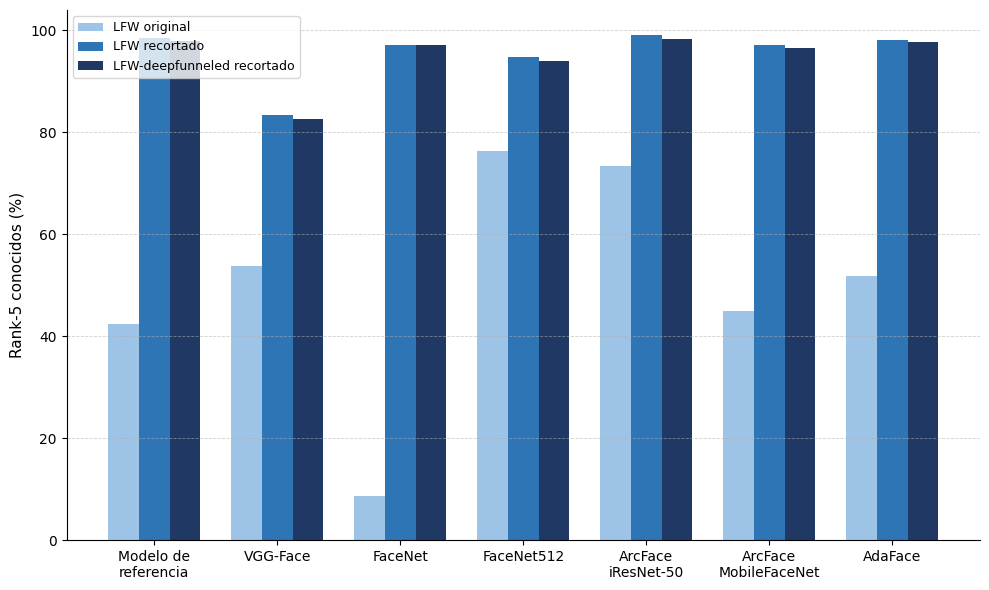

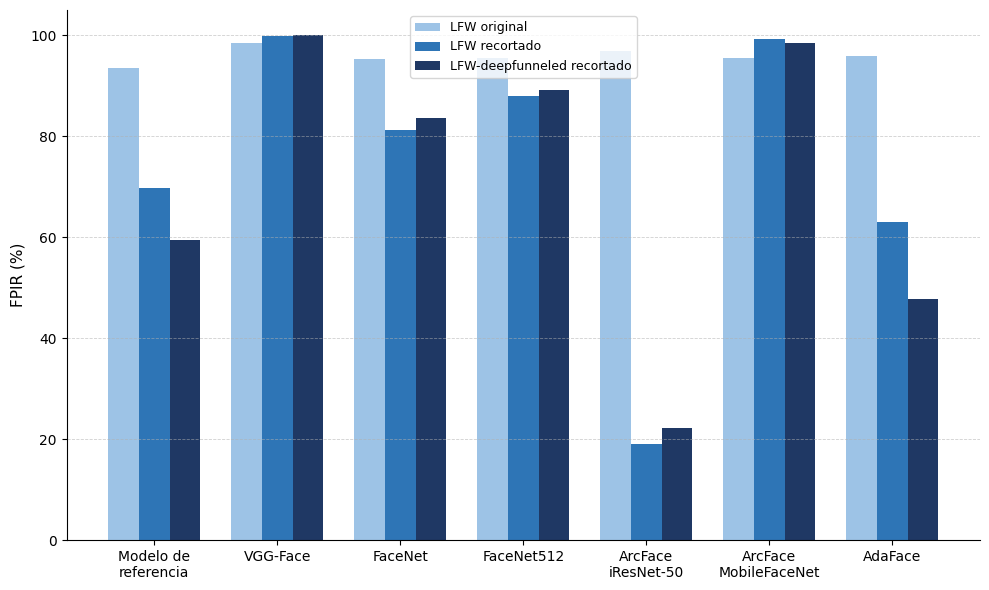

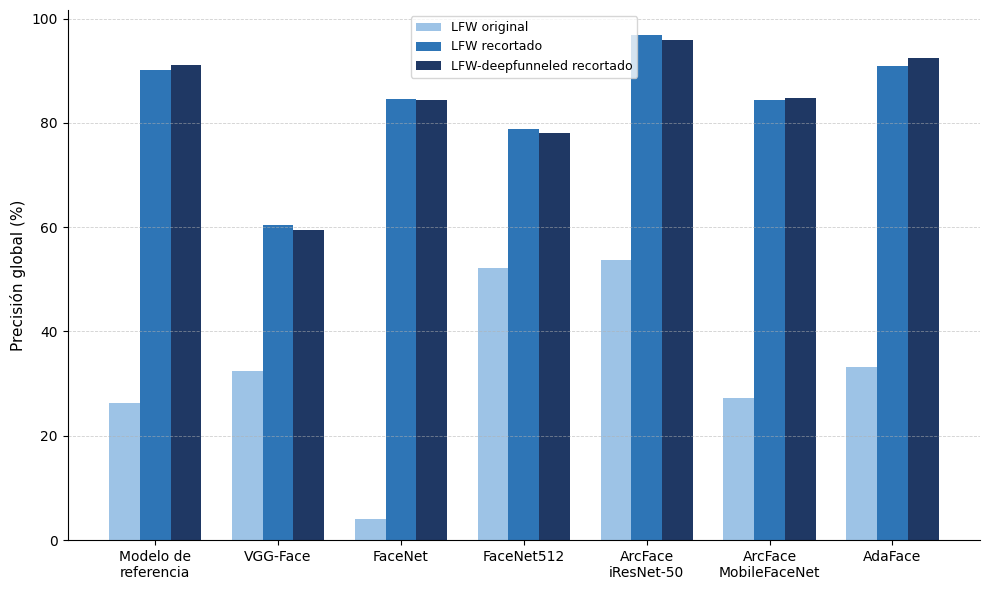

In [8]:
datasets = ['lfw_filtrado', 'lfw_cropped', 'lfw-deepfunneled_cropped'] #datasets a comparar 
labels_datasets = ['LFW original', 'LFW recortado', 'LFW-deepfunneled recortado']

modelos = ['empresa', 'VGG-Face', 'Facenet', 'Facenet512','ArcFace', 'ArcFace_s', 'AdaFace'] #modelos a comparar
labels_modelos = ['Modelo de\nreferencia', 'VGG-Face', 'FaceNet', 'FaceNet512','ArcFace\niResNet-50', 'ArcFace\nMobileFaceNet', 'AdaFace']

colores_barras = ['#9DC3E6', '#2E75B6', '#1F3864']
df_cos = df[df['metric'] == 'cosine'] #solo los resultados de distancia coseno
x = np.arange(len(modelos)) #posiciones en el eje X, una por modelo
width = 0.25 #ancho de cada barra

#metricas a comparar
metricas = [('TPIR','TPIR (%)','tpir_openset.pdf'),('rank5_conocidos','Rank-5 conocidos (%)','rank5_openset.pdf'),('FPIR','FPIR (%)','fpir_openset.pdf'),('acc_global','Precisión global (%)','accglobal_openset.pdf'),]

for col, ylabel, filename in metricas: #para cada métrica
    fig, ax = plt.subplots(figsize=(10, 6)) #crea la figura
    for i, (dataset, label_ds) in enumerate(zip(datasets, labels_datasets)): #para cada dataset
        valores = []
        for modelo in modelos:
            fila = df_cos[(df_cos['modelo'] == modelo) &(df_cos['dataset'] == dataset)] #valor del modelo y dataset
            valores.append(fila[col].values[0] if not fila.empty else 0)
        ax.bar(x + i * width, valores, width,label=label_ds, color=colores_barras[i]) #dibuja las barras

    ax.set_ylabel(ylabel, fontsize=11) 
    ax.set_xticks(x + width)  #centra las etiquetas del eje X respecto al grupo de barras
    ax.set_xticklabels(labels_modelos, rotation=0, ha='center', fontsize=10) #etiquetas del eje x
    ax.legend(fontsize=9) #leyenda
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.6) #rejilla horizontal
    ax.spines[['top', 'right']].set_visible(False) #oculta los bordes superior y derecho
    plt.tight_layout() #ajusta los márgenes
    # plt.savefig(filename, dpi=150, bbox_inches='tight')
    # print(f'Guardada: {filename}')
    plt.show()



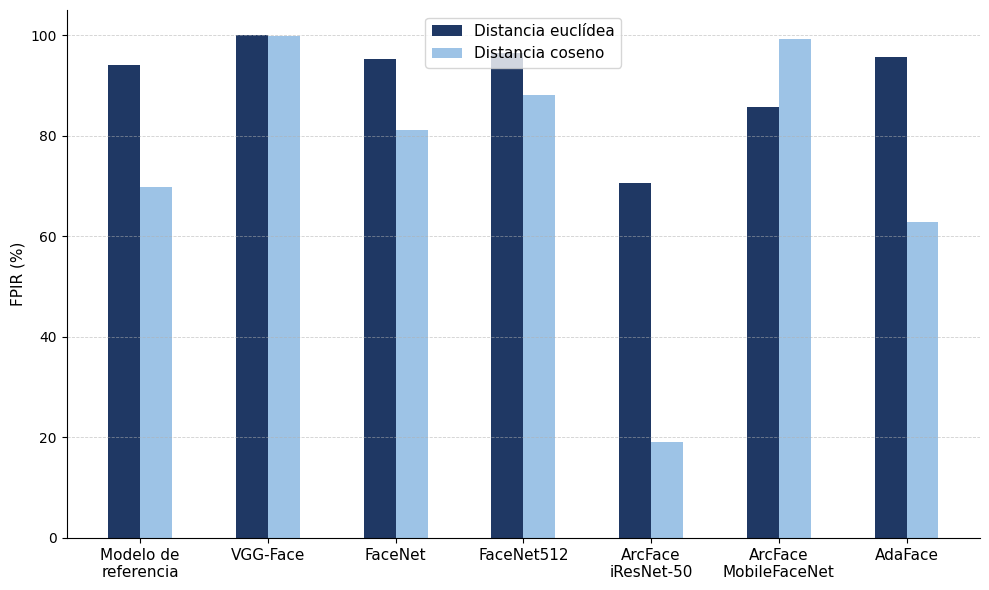

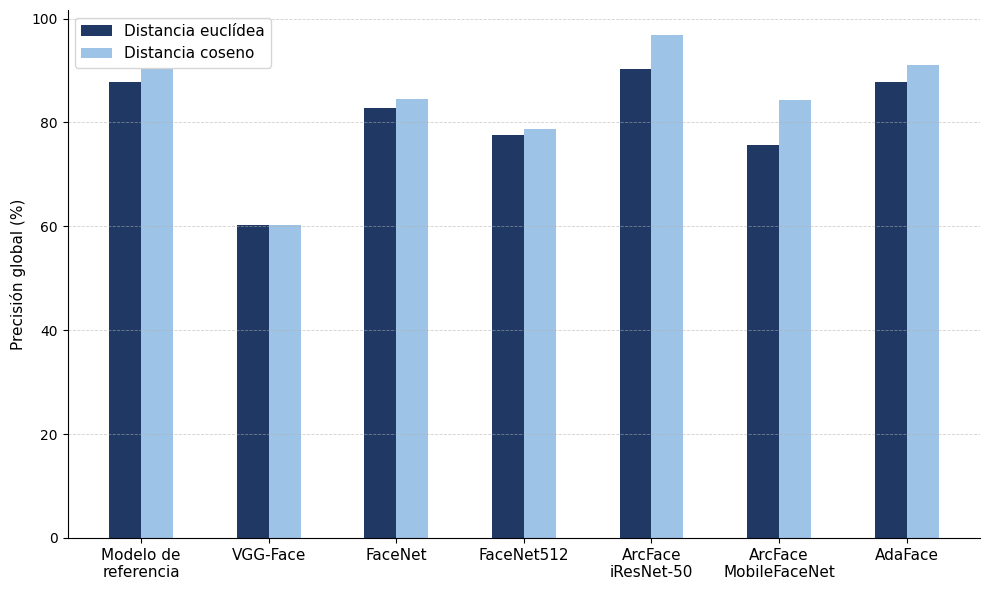

In [9]:
modelos = ['empresa', 'VGG-Face', 'Facenet', 'Facenet512','ArcFace', 'ArcFace_s', 'AdaFace'] #modelos a comparar
labels_modelos = ['Modelo de\nreferencia', 'VGG-Face', 'FaceNet', 'FaceNet512','ArcFace\niResNet-50', 'ArcFace\nMobileFaceNet', 'AdaFace']

colores_dist = ['#1F3864', '#9DC3E6']
#métricas a comparar
metricas_dist = [('FPIR','FPIR (%)','fpir_distancias_openset.pdf'),('acc_global', 'Precisión global (%)', 'accglobal_distancias_openset.pdf'),]

for col, ylabel, filename in metricas_dist: #para cada métrica
    fig, ax = plt.subplots(figsize=(10, 6)) #se crea una figura
    valores_euc = []
    valores_cos = []
    for modelo in modelos: #para cada modelo
        fila_euc = df[(df['modelo'] == modelo) & (df['dataset'] == 'lfw_cropped') &(df['metric'] == 'euclidean')] #fila de este modelo con distancia coseno
        fila_cos = df[(df['modelo'] == modelo) & (df['dataset'] == 'lfw_cropped') &(df['metric'] == 'cosine')] #fila de este modelo con distancia euclídea
        valores_euc.append(fila_euc[col].values[0] if not fila_euc.empty else 0)
        valores_cos.append(fila_cos[col].values[0] if not fila_cos.empty else 0)
    #se crean las barras
    ax.bar(x - width/2, valores_euc, width,label='Distancia euclídea', color=colores_dist[0])
    ax.bar(x + width/2, valores_cos, width, label='Distancia coseno', color=colores_dist[1])

    ax.set_ylabel(ylabel, fontsize=11) 
    ax.set_xticks(x) #centra las etiquetas del eje X respecto al grupo de barras
    ax.set_xticklabels(labels_modelos, rotation=0, ha='center', fontsize=11) #etiquetas eje X
    ax.legend(fontsize=11) #leyenda
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.6) #rejilla horizontal
    ax.spines[['top', 'right']].set_visible(False) #oculta los bordes superior y derecho del gráfico
    plt.tight_layout() #ajusta los márgenes
#     plt.savefig(filename, bbox_inches='tight')
#     print(f'Guardada: {filename}')
    plt.show()

#### 5.3.5 Comparativa visual de los resultados

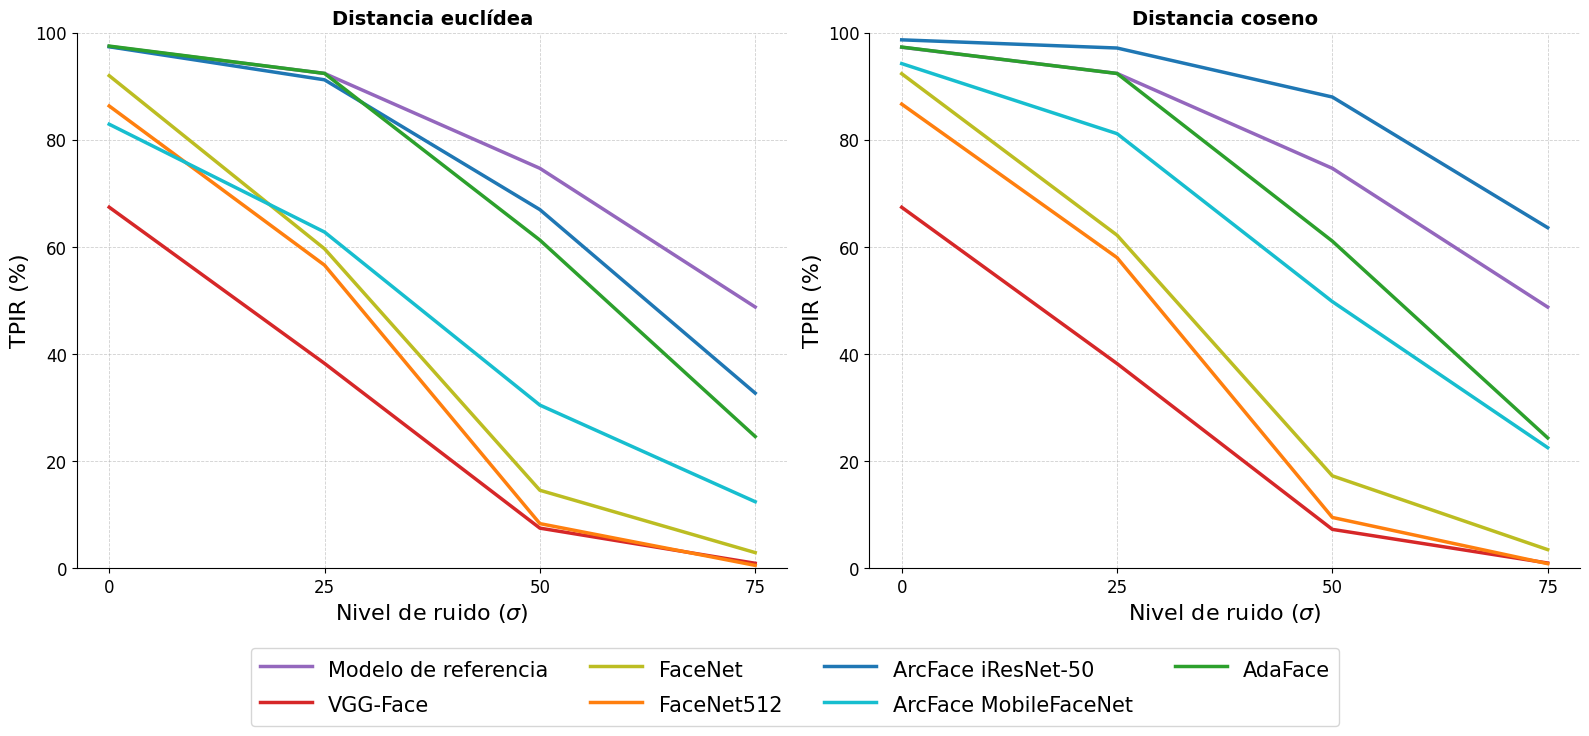

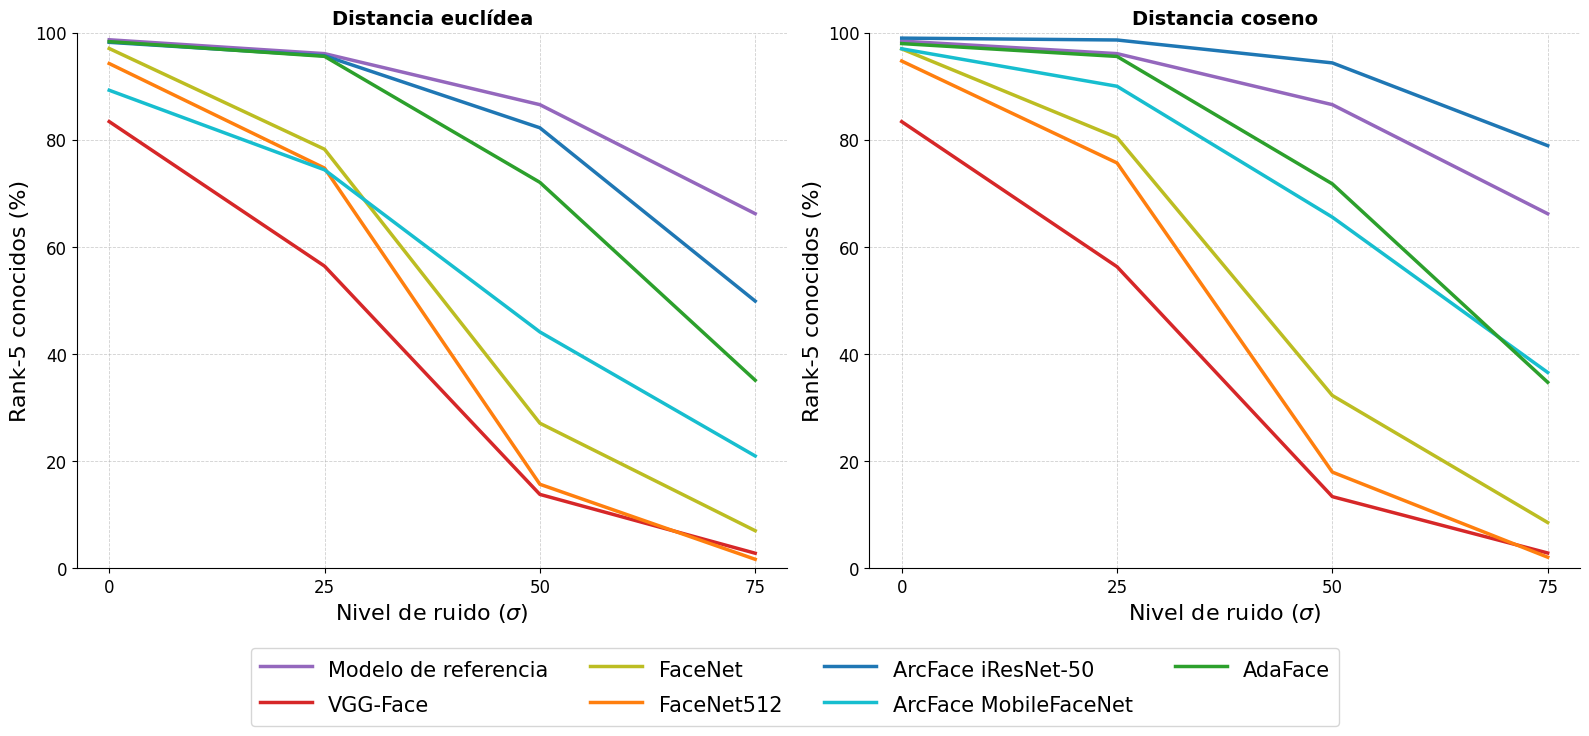

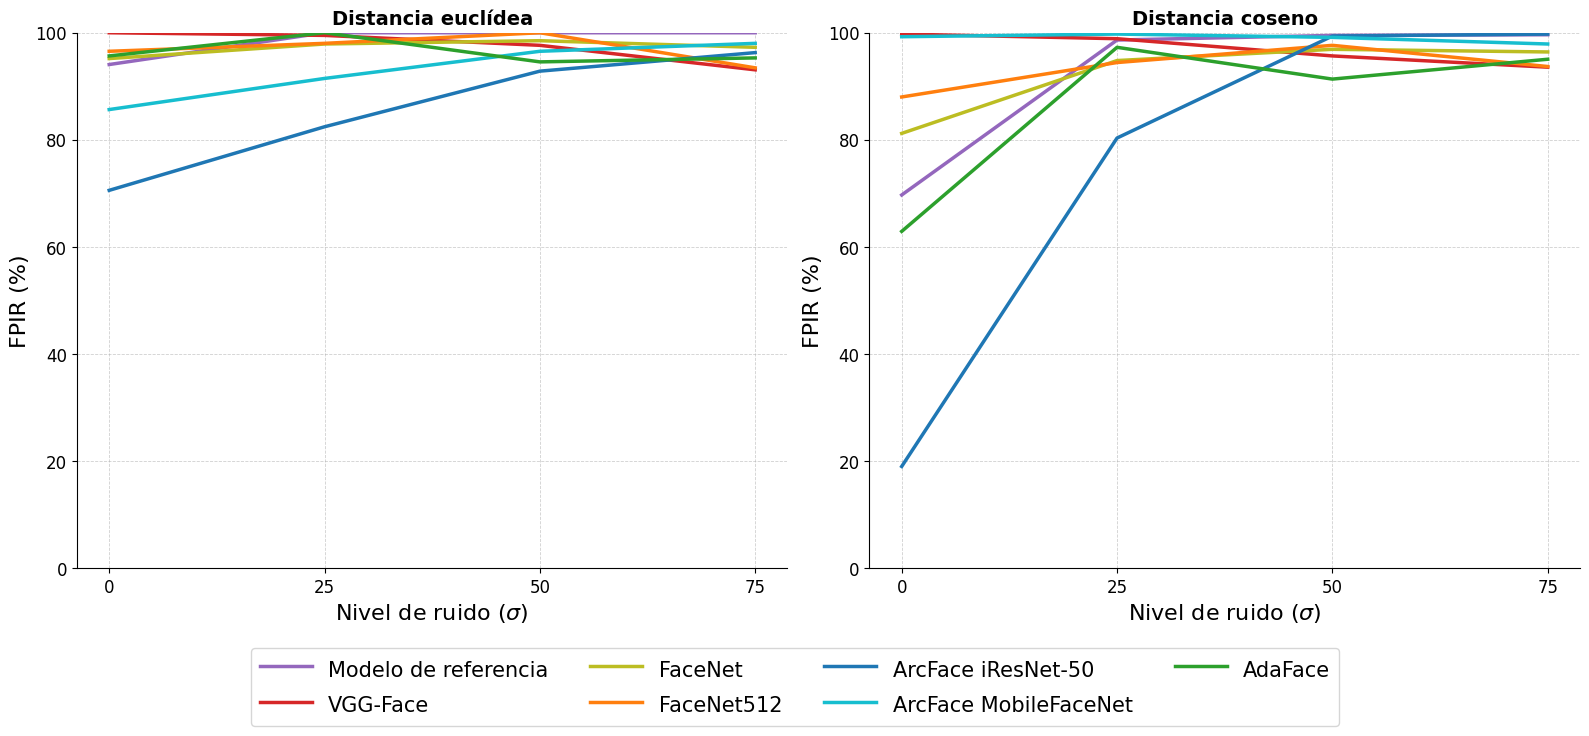

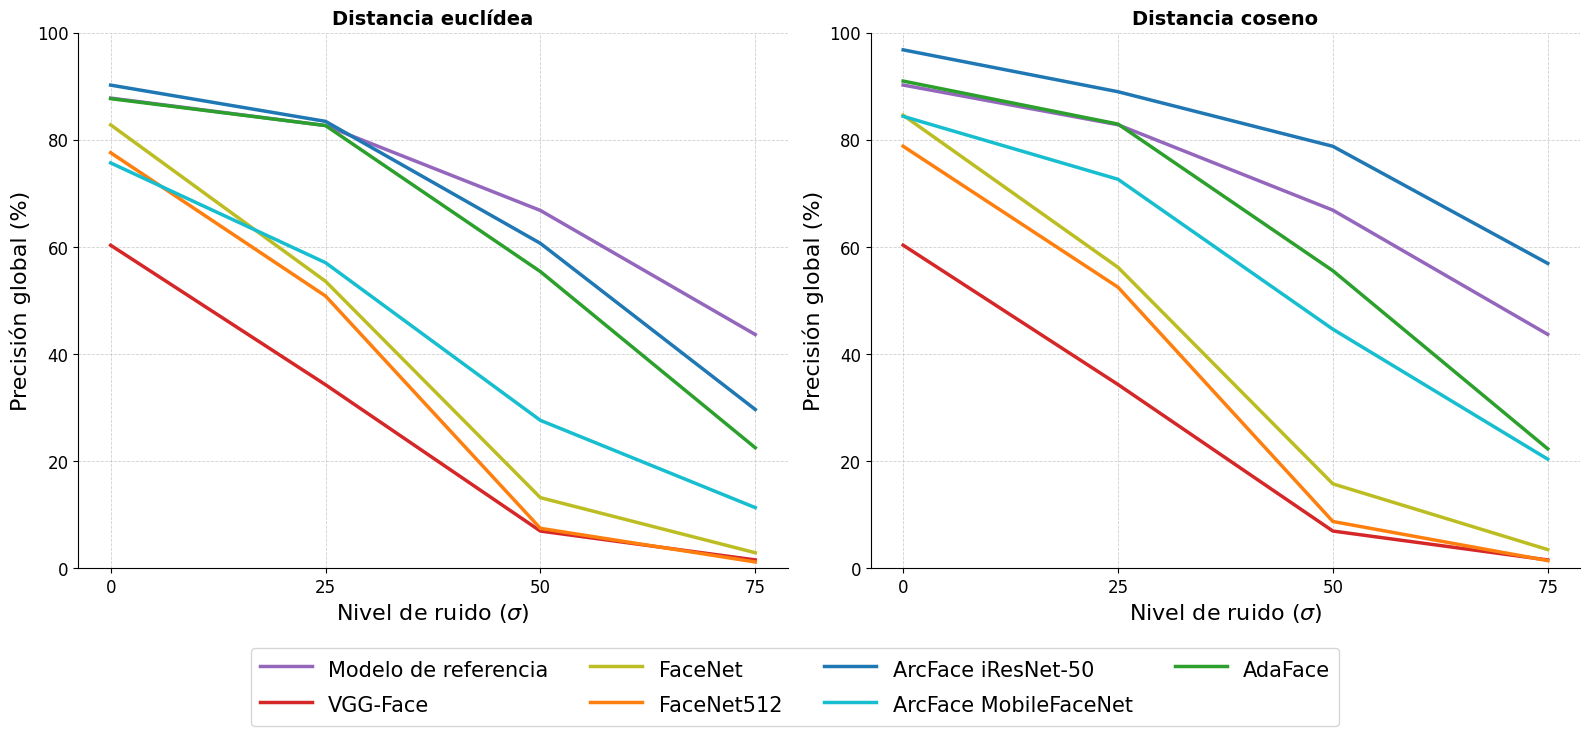

In [10]:
NOISE_LEVELS = [0, 25, 50, 75] #niveles de ruido
DATASETS = ['lfw_cropped', 'lfw_noisy_25', 'lfw_noisy_50', 'lfw_noisy_75'] #datasets

MODELOS = {'empresa':'Modelo de referencia','VGG-Face':'VGG-Face','Facenet':'FaceNet','Facenet512':'FaceNet512','ArcFace':'ArcFace iResNet-50','ArcFace_s':'ArcFace MobileFaceNet','AdaFace':'AdaFace',} #modelos a comparar

STYLE = {'empresa':{'color': '#9467BD'},'VGG-Face':{'color': '#D62728'},'Facenet':{'color': '#BCBD22'},'Facenet512': {'color': '#FF7F0E'},'ArcFace':{'color': '#1F77B4'},'ArcFace_s':{'color': '#17BECF'},'AdaFace':{'color': '#2CA02C'},}

#métricas a comparar
METRICAS = [
    {'col': 'TPIR','ylabel': 'TPIR (%)','filename':'tpir_ruido_openset.pdf'},
    {'col': 'rank5_conocidos','ylabel': 'Rank-5 conocidos (%)','filename':'rank5_ruido_openset.pdf'},
    {'col': 'FPIR','ylabel': 'FPIR (%)','filename':'fpir_ruido_openset.pdf'},
    {'col': 'acc_global','ylabel': 'Precisión global (%)','filename':'accglobal_ruido_openset.pdf'},
]

for cfg in METRICAS: #para cada métrica
    fig, axes = plt.subplots(1, 2, figsize=(16, 7)) #se crea una figura condos subplots
    handles, labels = None, None 
    for ax, distancia, titulo in zip(axes,['euclidean', 'cosine'],['Distancia euclídea', 'Distancia coseno']): #para cada grafico
        for modelo, label in MODELOS.items():
            valores = []
            for dataset in DATASETS: #para cada dataset
                fila = df[(df['modelo'] == modelo) &(df['dataset'] == dataset) & (df['metric'] == distancia)]
                valores.append(fila[cfg['col']].values[0] if not fila.empty else None)
            #crea la figura
            ax.plot(NOISE_LEVELS, valores,label=label,color=STYLE[modelo]['color'], linestyle='-',linewidth=2.5)

        ax.set_title(titulo, fontsize=14, fontweight='bold') #título del gráfico
        ax.set_xlabel('Nivel de ruido ($\\sigma$)', fontsize=16)
        ax.set_ylabel(cfg['ylabel'], fontsize=16)
        ax.set_xticks(NOISE_LEVELS) #una marca por nivel de ruido
        ax.tick_params(axis='both', labelsize=12)
        ax.set_ylim(0, 100) #eje y entre 0 y 100
        ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.6) #rejilla
        ax.spines[['top', 'right']].set_visible(False) #oculta los bordes superior y derecho

        if handles is None: #solo la primera vez (subgráfico de euclídea) se guarda la leyenda
            handles, labels = ax.get_legend_handles_labels()
    #configuración de la leyenda
    fig.legend(handles, labels, loc='lower center',ncol=4, fontsize=15,bbox_to_anchor=(0.5, -0.06),handlelength=2.5,handleheight=1.5, markerscale=2)

    plt.tight_layout() #ajusta los márgenes
    plt.subplots_adjust(bottom=0.18) #deja espacio extra abajo para la leyenda común
    save_path =  cfg['filename']
    #plt.savefig(save_path, dpi=150, bbox_inches='tight')
    #print(f'Guardada: {save_path}')
    plt.show()